# APS1 — Classificador de falhas em máquina rotativa

Este notebook cobre as etapas principais solicitadas na APS:

1. **Panorama geral:** definição do problema, hipóteses e métricas.
2. **Exploração dos dados:** inspeção, estatísticas e gráficos.
3. **Pré-processamento:** limpeza, separação dos dados, padronização e seleção simples de atributos.
4. **Desenvolvimento do modelo:** KNN, SVM e Decision Tree, com avaliação e comparação.
5. **Função de classificação:** recebe valores de atributos e retorna a condição prevista.

O dataset foi fornecido junto com o projeto. As condições são: Normal, Desacoplado, Sobrecarga, Desbalanceado e Desalinhado.

## 1. Panorama geral do problema

O objetivo é construir um classificador supervisionado multiclasses para identificar a condição operacional de uma máquina rotativa a partir de atributos elétricos e de vibração.

**Hipóteses iniciais:**

- As grandezas elétricas e vibracionais apresentam padrões diferentes entre as cinco condições.
- O KNN deve se beneficiar da padronização, pois usa distâncias.
- O SVM também deve se beneficiar da padronização, pois trabalha com margens e atributos em escalas diferentes.
- A árvore de decisão não precisa de padronização e pode indicar regras de decisão.
- Alguns atributos podem ser redundantes; por isso será feita uma seleção simples dos melhores atributos.

A **acurácia** será a métrica principal, porque as classes têm a mesma quantidade de exemplos. Também serão apresentados o F1-macro e a matriz de confusão, para verificar o comportamento em cada classe.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.base import clone
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, learning_curve
from sklearn.preprocessing import label_binarize
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    precision_score,
    recall_score,
    roc_curve,
    roc_auc_score,
    auc,
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)
plt.style.use("ggplot")

## 2. Leitura e entendimento do dataset

Embora o arquivo tenha extensão `.xls`, seu conteúdo é um CSV separado por vírgulas. Por isso a leitura é feita com `pd.read_csv`, que é a forma que funciona para este arquivo específico.

In [2]:
df = pd.read_csv("Dataset APS1_Sinais Eletricos e Vibracao_csv.xls")
df["tipo_setup"] = df["tipo_setup"].astype(int)

nomes_classes = {
    0: "Normal",
    1: "Desacoplado",
    2: "Sobrecarga",
    3: "Desbalanceado",
    4: "Desalinhado",
}
df["condicao"] = df["tipo_setup"].map(nomes_classes)

print(f"Dimensões: {df.shape[0]} registros e {df.shape[1]} colunas")
df.head(5)

Dimensões: 2505 registros e 21 colunas


,tempo_s,tipo_setup,I_entrada_A,P_entrada_W,I_saida_A,DesvPad_I_entrada_A,DesvPad _P_entrada_W,DesvPad _I_saida_A,Amp_I_entrada_A,Amp_P_entrada_W,Amp_I_saida_A,Kurtosis_I_entrada_A,Kurtosis_P_entrada_W,Kurtosis_I_saida_A,Mag_S1_f1_dBrms,Mag_S1_f2_dBrms,Mag_S1_f3_dBrms,Mag_S2_f1_dBrms,Mag_S2_f2_dBrms,Mag_S2_f3_dBrms,condicao
0,0.00,0,0.44905,63.67320,1.43660,0.042740,21.869566,0.113479,0.175,91.738,0.406,12.474475,15.435837,4.223108,-50.647991,-63.189443,-47.864704,-59.629807,-73.010381,-49.583755,Normal
1,0.08,0,0.44610,69.40320,1.67860,0.048945,1.600020,0.854342,0.227,7.359,3.843,20.070610,13.335535,16.966677,-50.696943,-63.340003,-48.313132,-59.591150,-72.360239,-49.473893,Normal
2,0.16,0,0.45175,69.11385,1.39950,0.042337,5.220348,0.284000,0.207,24.185,1.395,19.087723,7.345771,11.032327,-47.724322,-62.837371,-48.384219,-55.194912,-63.127903,-48.083630,Normal
3,0.24,0,0.43510,68.85665,1.39705,0.063224,3.437546,0.219507,0.228,16.040,0.973,6.869051,19.849528,9.136137,-47.652608,-62.613368,-48.768793,-55.275822,-63.310116,-47.937933,Normal
4,0.32,0,0.45055,70.52860,1.43375,0.048497,1.240032,0.111967,0.222,4.394,0.425,20.205840,2.325535,2.818658,-47.019446,-61.314274,-49.016646,-54.665312,-60.825200,-47.886619,Normal


In [3]:
print("Tipos das colunas:")
display(df.dtypes.to_frame("tipo"))

print("Informações gerais:")
df.info()

Tipos das colunas:


,tipo
tempo_s,float64
tipo_setup,int64
I_entrada_A,float64
P_entrada_W,float64
I_saida_A,float64
DesvPad_I_entrada_A,float64
DesvPad _P_entrada_W,float64
DesvPad _I_saida_A,float64
Amp_I_entrada_A,float64
Amp_P_entrada_W,float64


Informações gerais:
<class 'pandas.DataFrame'>
RangeIndex: 2505 entries, 0 to 2504
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   tempo_s               2505 non-null   float64
 1   tipo_setup            2505 non-null   int64  
 2   I_entrada_A           2505 non-null   float64
 3   P_entrada_W           2505 non-null   float64
 4   I_saida_A             2505 non-null   float64
 5   DesvPad_I_entrada_A   2505 non-null   float64
 6   DesvPad _P_entrada_W  2505 non-null   float64
 7   DesvPad _I_saida_A    2505 non-null   float64
 8   Amp_I_entrada_A       2505 non-null   float64
 9   Amp_P_entrada_W       2505 non-null   float64
 10  Amp_I_saida_A         2505 non-null   float64
 11  Kurtosis_I_entrada_A  2505 non-null   float64
 12  Kurtosis_P_entrada_W  2505 non-null   float64
 13  Kurtosis_I_saida_A    2505 non-null   float64
 14  Mag_S1_f1_dBrms       2505 non-null   float64
 15  Mag_S1_f2_dB

## 3. Exploração dos dados

Nesta etapa verificamos qualidade, distribuição das classes, escalas dos atributos, possíveis relações entre variáveis e diferenças visuais entre as condições.

In [4]:
print(f"Valores ausentes: {df.isna().sum().sum()}")
print(f"Linhas duplicadas: {df.duplicated().sum()}")

distribuicao = (
    df.groupby(["tipo_setup", "condicao"])
      .size()
      .rename("quantidade")
      .reset_index()
)
display(distribuicao)

Valores ausentes: 0
Linhas duplicadas: 0


,tipo_setup,condicao,quantidade
0,0,Normal,501
1,1,Desacoplado,501
2,2,Sobrecarga,501
3,3,Desbalanceado,501
4,4,Desalinhado,501


In [5]:
atributos_originais = [
    coluna for coluna in df.columns
    if coluna not in ["tempo_s", "tipo_setup", "condicao"]
]

print("Resumo estatístico dos atributos numéricos:")
display(df[atributos_originais].describe().T.round(3))

resumo_aula_9 = pd.DataFrame({
    "media": df[atributos_originais].mean(),
    "mediana": df[atributos_originais].median(),
    "desvio_padrao": df[atributos_originais].std(),
    "assimetria": df[atributos_originais].skew(),
    "curtose": df[atributos_originais].kurt(),
})
print("Média, mediana, desvio-padrão, assimetria e curtose:")
display(resumo_aula_9.round(3))

Resumo estatístico dos atributos numéricos:


,count,mean,std,min,25%,50%,75%,max
I_entrada_A,2505.0,0.467,0.038,0.262,0.446,0.457,0.472,0.626
P_entrada_W,2505.0,71.095,6.370,38.470,67.308,69.612,73.029,96.652
I_saida_A,2505.0,1.510,0.138,0.811,1.420,1.479,1.591,2.118
DesvPad_I_entrada_A,2505.0,0.063,0.058,0.001,0.041,0.057,0.071,0.860
DesvPad _P_entrada_W,2505.0,10.031,11.106,0.543,2.689,8.408,12.983,149.492
DesvPad _I_saida_A,2505.0,0.496,0.375,0.064,0.154,0.377,0.880,2.008
Amp_I_entrada_A,2505.0,0.280,0.269,0.005,0.183,0.244,0.302,3.881
Amp_P_entrada_W,2505.0,46.372,52.036,1.893,12.789,38.618,58.301,672.213
Amp_I_saida_A,2505.0,2.226,1.768,0.244,0.596,1.745,4.108,10.687
Kurtosis_I_entrada_A,2505.0,12.051,5.231,1.660,7.971,10.702,15.928,22.979


Média, mediana, desvio-padrão, assimetria e curtose:


,media,mediana,desvio_padrao,assimetria,curtose
I_entrada_A,0.467,0.457,0.038,1.042,2.155
P_entrada_W,71.095,69.612,6.370,0.827,1.396
I_saida_A,1.510,1.479,0.138,0.652,2.289
DesvPad_I_entrada_A,0.063,0.057,0.058,7.734,83.354
DesvPad _P_entrada_W,10.031,8.408,11.106,4.205,31.198
DesvPad _I_saida_A,0.496,0.377,0.375,0.764,-0.431
Amp_I_entrada_A,0.280,0.244,0.269,7.512,78.737
Amp_P_entrada_W,46.372,38.618,52.036,4.089,28.821
Amp_I_saida_A,2.226,1.745,1.768,0.880,0.446
Kurtosis_I_entrada_A,12.051,10.702,5.231,0.534,-0.781


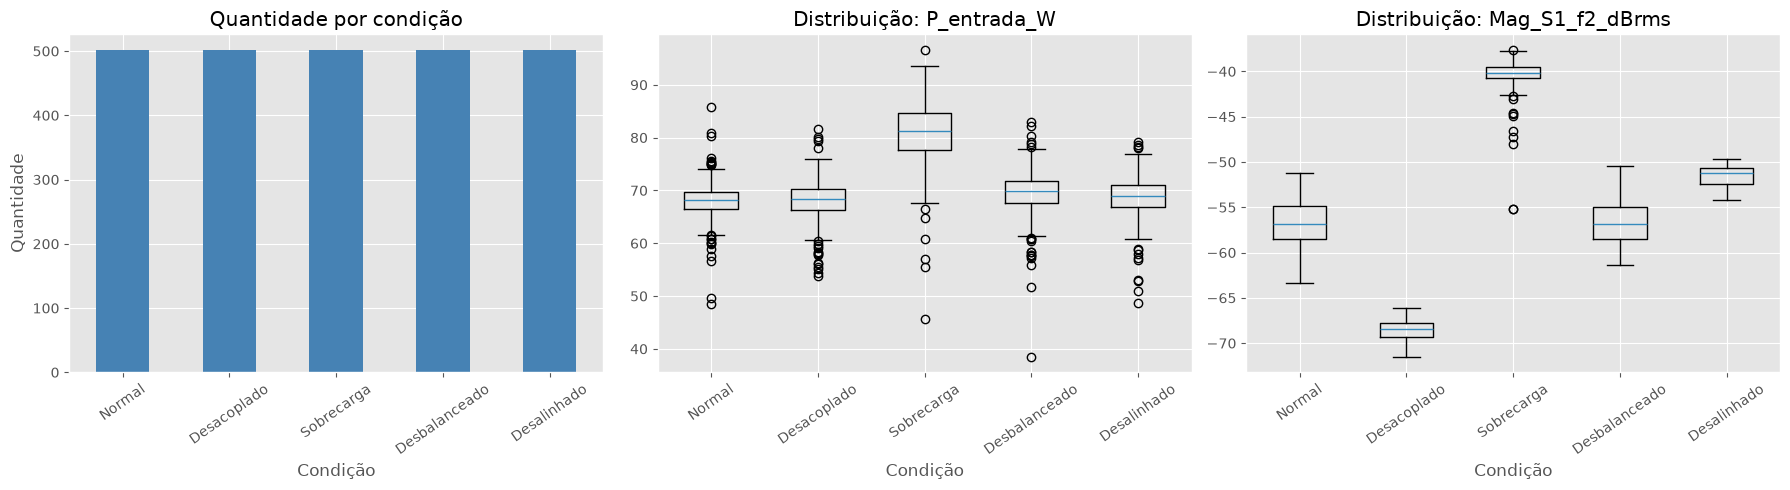

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df["condicao"].value_counts().reindex(nomes_classes.values()).plot(
    kind="bar", ax=axes[0], color="steelblue"
)
axes[0].set_title("Quantidade por condição")
axes[0].set_xlabel("Condição")
axes[0].set_ylabel("Quantidade")
axes[0].tick_params(axis="x", rotation=35)

colunas_boxplot = ["P_entrada_W", "Mag_S1_f2_dBrms"]
for eixo, coluna in zip(axes[1:], colunas_boxplot):
    dados_por_classe = [
        df.loc[df["tipo_setup"] == codigo, coluna]
        for codigo in nomes_classes
    ]
    eixo.boxplot(dados_por_classe)
    eixo.set_xticks(range(1, len(nomes_classes) + 1))
    eixo.set_xticklabels(list(nomes_classes.values()))
    eixo.set_title(f"Distribuição: {coluna}")
    eixo.set_xlabel("Condição")
    eixo.tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

### Outros gráficos de exploração

Os histogramas mostram a distribuição dos valores e o gráfico de dispersão permite observar a relação entre dois atributos, colorindo os pontos pela condição da máquina. Também é apresentado um boxplot padronizado com todos os atributos.

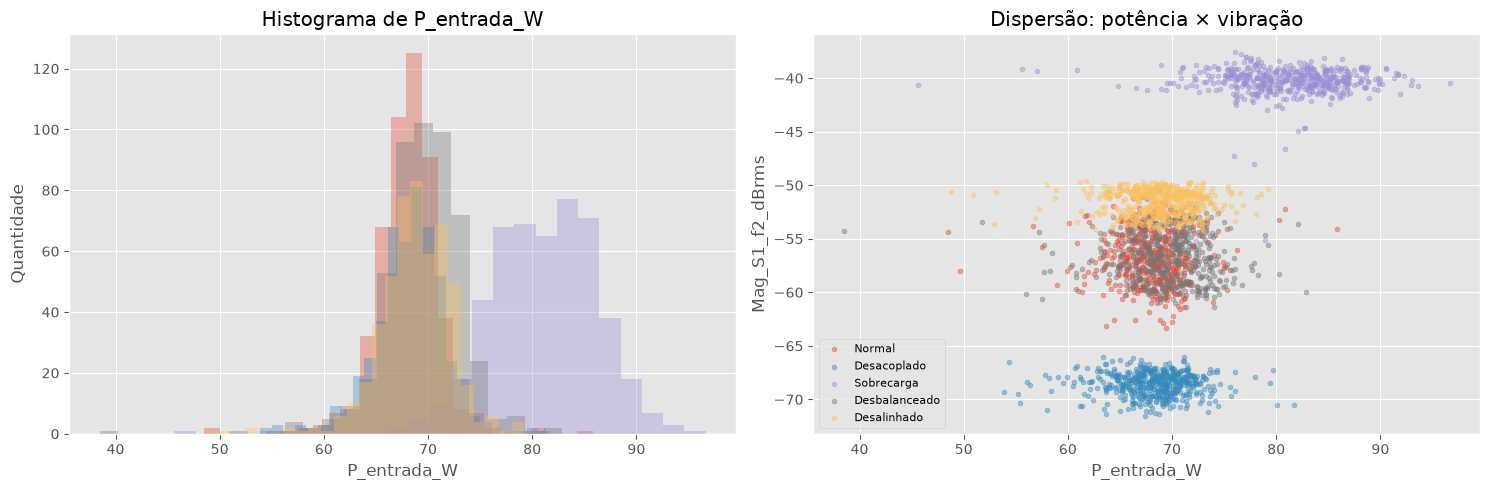

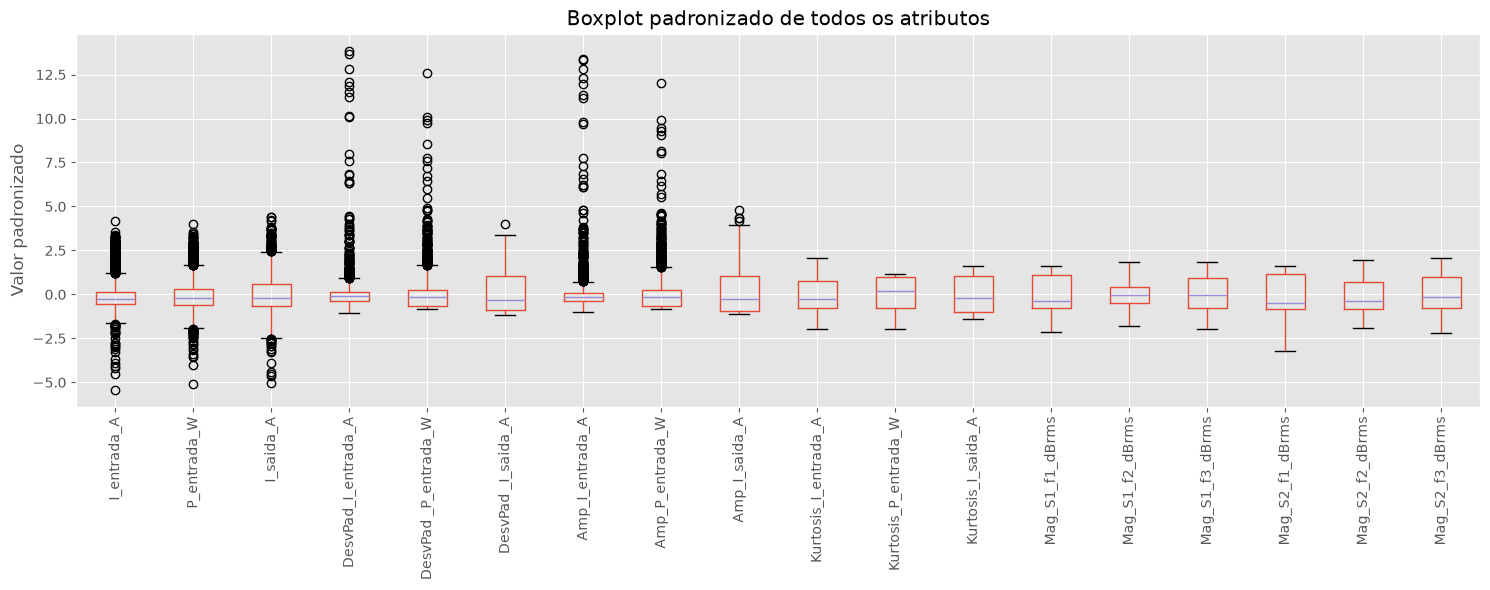

Quantidade de possíveis outliers pelo critério 1,5 × IQR:


,quantidade
I_entrada_A,396
P_entrada_W,277
Amp_I_entrada_A,158
Amp_P_entrada_W,139
DesvPad _P_entrada_W,129
DesvPad_I_entrada_A,121
I_saida_A,81
Amp_I_saida_A,4
DesvPad _I_saida_A,1
Kurtosis_I_entrada_A,0


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for codigo, nome in nomes_classes.items():
    dados_classe = df[df["tipo_setup"] == codigo]
    axes[0].hist(
        dados_classe["P_entrada_W"],
        bins=25,
        alpha=0.35,
        label=nome,
    )
    axes[1].scatter(
        dados_classe["P_entrada_W"],
        dados_classe["Mag_S1_f2_dBrms"],
        s=12,
        alpha=0.45,
        label=nome,
    )

axes[0].set_title("Histograma de P_entrada_W")
axes[0].set_xlabel("P_entrada_W")
axes[0].set_ylabel("Quantidade")
axes[1].set_title("Dispersão: potência × vibração")
axes[1].set_xlabel("P_entrada_W")
axes[1].set_ylabel("Mag_S1_f2_dBrms")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

dados_padronizados = pd.DataFrame(
    StandardScaler().fit_transform(df[atributos_originais]),
    columns=atributos_originais,
)
plt.figure(figsize=(15, 6))
dados_padronizados.boxplot(rot=90)
plt.title("Boxplot padronizado de todos os atributos")
plt.ylabel("Valor padronizado")
plt.tight_layout()
plt.show()

q1 = df[atributos_originais].quantile(0.25)
q3 = df[atributos_originais].quantile(0.75)
iqr = q3 - q1
outliers_iqr = ((df[atributos_originais] < q1 - 1.5 * iqr) | (df[atributos_originais] > q3 + 1.5 * iqr)).sum()
print("Quantidade de possíveis outliers pelo critério 1,5 × IQR:")
display(outliers_iqr.sort_values(ascending=False).to_frame("quantidade"))

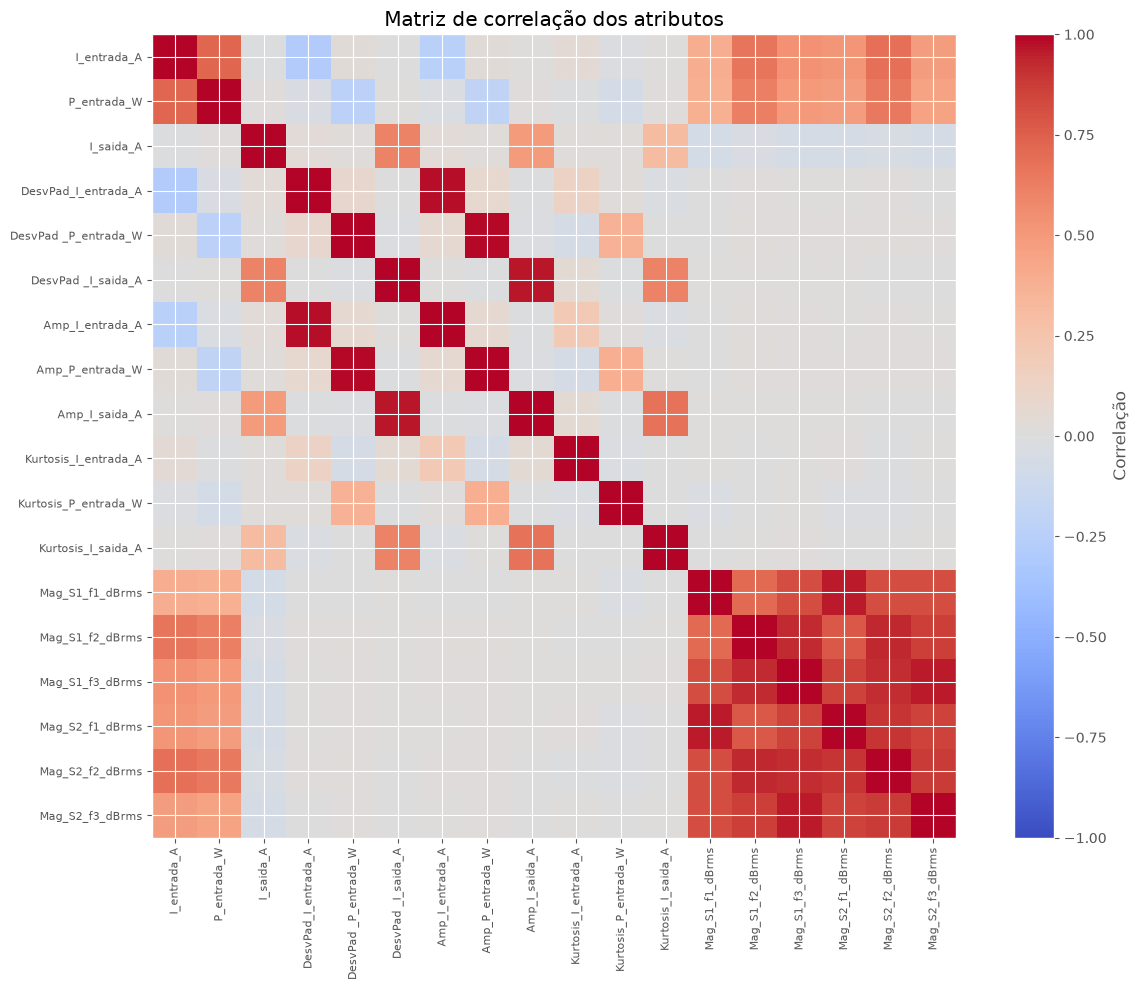

Pares com maior correlação absoluta:


,atributo_1,atributo_2,correlacao,correlacao_abs
64,DesvPad _P_entrada_W,Amp_P_entrada_W,0.989,0.989
50,DesvPad_I_entrada_A,Amp_I_entrada_A,0.983,0.983
77,DesvPad _I_saida_A,Amp_I_saida_A,0.969,0.969
149,Mag_S1_f3_dBrms,Mag_S2_f3_dBrms,0.957,0.957
140,Mag_S1_f1_dBrms,Mag_S2_f1_dBrms,0.955,0.955
145,Mag_S1_f2_dBrms,Mag_S2_f2_dBrms,0.936,0.936
143,Mag_S1_f2_dBrms,Mag_S1_f3_dBrms,0.926,0.926
148,Mag_S1_f3_dBrms,Mag_S2_f2_dBrms,0.914,0.914
150,Mag_S2_f1_dBrms,Mag_S2_f2_dBrms,0.891,0.891
152,Mag_S2_f2_dBrms,Mag_S2_f3_dBrms,0.880,0.880


In [8]:
correlacao = df[atributos_originais].corr()

fig, ax = plt.subplots(figsize=(13, 10))
imagem = ax.imshow(correlacao, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(correlacao.columns)))
ax.set_yticks(range(len(correlacao.columns)))
ax.set_xticklabels(correlacao.columns, rotation=90, fontsize=8)
ax.set_yticklabels(correlacao.columns, fontsize=8)
ax.set_title("Matriz de correlação dos atributos")
fig.colorbar(imagem, ax=ax, label="Correlação")
plt.tight_layout()
plt.show()

pares = []
for i in range(len(correlacao.columns)):
    for j in range(i + 1, len(correlacao.columns)):
        valor = correlacao.iloc[i, j]
        pares.append({
            "atributo_1": correlacao.columns[i],
            "atributo_2": correlacao.columns[j],
            "correlacao": valor,
            "correlacao_abs": abs(valor),
        })

print("Pares com maior correlação absoluta:")
display(
    pd.DataFrame(pares)
      .sort_values("correlacao_abs", ascending=False)
      .head(10)
      .round(3)
)

### Interpretação inicial

- O conjunto está balanceado: cada condição possui 501 registros.
- Não foram encontrados valores ausentes ou linhas duplicadas.
- Os atributos possuem escalas bastante diferentes. Por exemplo, potência, corrente e magnitudes de vibração não estão na mesma ordem de grandeza.
- Há grupos de atributos muito correlacionados, como desvios-padrão/amplitudes e magnitudes de vibração. Isso indica possível redundância.
- `tempo_s` varia de 0 a 40 s dentro de cada condição e funciona como uma referência temporal do registro. Ele não será usado como atributo previsor, para que o modelo aprenda os sinais da máquina e não a posição temporal.

## 4. Pré-processamento

O arquivo já contém atributos derivados dos sinais, como desvio-padrão, amplitude, curtose e magnitudes de vibração. Assim, não é necessário inventar novas variáveis nesta primeira versão.

Será feito o seguinte:

- remover a coluna temporal `tempo_s` e a coluna textual auxiliar `condicao`;
- remover duplicatas e linhas com valores ausentes;
- separar previsores (`X`) e rótulo (`y`);
- dividir os dados em treino e teste, mantendo a proporção das classes;
- padronizar os atributos dentro de um `Pipeline` para KNN e SVM;
- testar uma versão do KNN com os 5 melhores atributos pelo teste ANOVA (`SelectKBest`).

In [9]:
df_modelo = df.drop(columns=["condicao"]).copy()
linhas_antes = len(df_modelo)
df_modelo = df_modelo.drop_duplicates().dropna()

X = df_modelo[atributos_originais].copy()
y = df_modelo["tipo_setup"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print(f"Linhas antes da limpeza: {linhas_antes}")
print(f"Linhas depois da limpeza: {len(df_modelo)}")
print(f"Treino: {X_train.shape[0]} registros")
print(f"Teste: {X_test.shape[0]} registros")
print(f"Quantidade de atributos usados: {X.shape[1]}")

print("Distribuição no treino:")
display(y_train.map(nomes_classes).value_counts())
print("Distribuição no teste:")
display(y_test.map(nomes_classes).value_counts())

Linhas antes da limpeza: 2505
Linhas depois da limpeza: 2505
Treino: 2004 registros
Teste: 501 registros
Quantidade de atributos usados: 18
Distribuição no treino:


tipo_setup
Desacoplado      401
Desalinhado      401
Normal           401
Sobrecarga       401
Desbalanceado    400
Name: count, dtype: int64

Distribuição no teste:


tipo_setup
Desbalanceado    101
Desalinhado      100
Sobrecarga       100
Desacoplado      100
Normal           100
Name: count, dtype: int64

## 5. Desenvolvimento dos modelos

Serão comparados quatro modelos simples:

1. KNN com `k=7` e todos os atributos;
2. KNN com `k=3` e os 5 melhores atributos, após uma comparação simples de valores de `k`;
3. SVM com kernel linear;
4. Decision Tree sem limitar a profundidade.

A seleção de atributos e a padronização ficam dentro dos pipelines. Assim, no momento da validação, essas etapas são ajustadas somente com os dados de treino de cada divisão.

In [10]:
modelos = {
    "KNN (7-NN, todos os atributos)": Pipeline([
        ("escala", StandardScaler()),
        ("modelo", KNeighborsClassifier(n_neighbors=7)),
    ]),
    "KNN (3-NN, 5 atributos selecionados)": Pipeline([
        ("selecao", SelectKBest(score_func=f_classif, k=5)),
        ("escala", StandardScaler()),
        ("modelo", KNeighborsClassifier(n_neighbors=3)),
    ]),
    "SVM linear": Pipeline([
        ("escala", StandardScaler()),
        ("modelo", SVC(kernel="linear", C=1.0)),
    ]),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
}

In [11]:
resultados = []
previsoes = {}
modelos_treinados = {}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    previsao = modelo.predict(X_test)
    previsoes[nome] = previsao
    modelos_treinados[nome] = modelo

    scores_cv = cross_val_score(modelo, X, y, cv=cv, scoring="accuracy")
    resultados.append({
        "modelo": nome,
        "acuracia_treino": modelo.score(X_train, y_train),
        "acuracia_teste": accuracy_score(y_test, previsao),
        "f1_macro_teste": f1_score(y_test, previsao, average="macro"),
        "precisao_macro_teste": precision_score(y_test, previsao, average="macro"),
        "recall_macro_teste": recall_score(y_test, previsao, average="macro"),
        "acuracia_cv_media": scores_cv.mean(),
        "acuracia_cv_desvio": scores_cv.std(),
    })

resultados = (
    pd.DataFrame(resultados)
      .sort_values("acuracia_teste", ascending=False)
      .reset_index(drop=True)
)

print("Comparação dos modelos:")
display(resultados.round(4))

Comparação dos modelos:


,modelo,acuracia_treino,acuracia_teste,f1_macro_teste,precisao_macro_teste,recall_macro_teste,acuracia_cv_media,acuracia_cv_desvio
0,"KNN (3-NN, 5 atributos selecionados)",0.9865,0.9661,0.9662,0.9663,0.9661,0.9681,0.0073
1,Decision Tree,1.0000,0.9341,0.9343,0.9343,0.9343,0.9285,0.0093
2,SVM linear,0.9436,0.9321,0.9323,0.9328,0.9323,0.9373,0.0083
3,"KNN (7-NN, todos os atributos)",0.8972,0.8323,0.8332,0.8337,0.8328,0.8355,0.0076


## 6. Ajuste simples dos hiperparâmetros

Para não escolher parâmetros olhando diretamente para o teste, os valores abaixo são comparados usando somente o conjunto de treino com validação cruzada. A escolha final usa a média da acurácia e o desvio-padrão.

In [12]:
ajuste_knn = []
for k in [3, 5, 7, 9, 11]:
    modelo = Pipeline([
        ("selecao", SelectKBest(score_func=f_classif, k=5)),
        ("escala", StandardScaler()),
        ("modelo", KNeighborsClassifier(n_neighbors=k)),
    ])
    scores = cross_val_score(modelo, X_train, y_train, cv=cv, scoring="accuracy")
    modelo.fit(X_train, y_train)
    ajuste_knn.append({
        "k": k,
        "cv_media": scores.mean(),
        "cv_desvio": scores.std(),
        "acuracia_teste": modelo.score(X_test, y_test),
    })

ajuste_knn = pd.DataFrame(ajuste_knn).sort_values("cv_media", ascending=False)
print("KNN: comparação de k usando os 5 atributos selecionados:")
display(ajuste_knn.round(4))
print(f"Melhor k pela validação cruzada no treino: {int(ajuste_knn.iloc[0]['k'])}")

KNN: comparação de k usando os 5 atributos selecionados:


,k,cv_media,cv_desvio,acuracia_teste
0,3,0.9481,0.0110,0.9661
1,5,0.9421,0.0082,0.9721
2,7,0.9321,0.0111,0.9481
3,9,0.9311,0.0103,0.9421
4,11,0.9301,0.0104,0.9461


Melhor k pela validação cruzada no treino: 3


In [13]:
ajuste_svm = []
for valor_c in [0.1, 1, 10]:
    modelo = Pipeline([
        ("escala", StandardScaler()),
        ("modelo", SVC(kernel="linear", C=valor_c)),
    ])
    scores = cross_val_score(modelo, X_train, y_train, cv=cv, scoring="accuracy")
    modelo.fit(X_train, y_train)
    ajuste_svm.append({
        "C": valor_c,
        "cv_media": scores.mean(),
        "cv_desvio": scores.std(),
        "acuracia_teste": modelo.score(X_test, y_test),
    })

ajuste_svm = pd.DataFrame(ajuste_svm).sort_values("cv_media", ascending=False)
print("SVM linear: comparação do parâmetro C:")
display(ajuste_svm.round(4))

ajuste_arvore = []
for profundidade in [3, 5, 8, None]:
    modelo = DecisionTreeClassifier(random_state=42, max_depth=profundidade)
    scores = cross_val_score(modelo, X_train, y_train, cv=cv, scoring="accuracy")
    modelo.fit(X_train, y_train)
    ajuste_arvore.append({
        "max_depth": profundidade,
        "cv_media": scores.mean(),
        "cv_desvio": scores.std(),
        "acuracia_teste": modelo.score(X_test, y_test),
    })

ajuste_arvore = pd.DataFrame(ajuste_arvore).sort_values("cv_media", ascending=False)
print("Decision Tree: comparação da profundidade máxima:")
display(ajuste_arvore.round(4))

SVM linear: comparação do parâmetro C:


,C,cv_media,cv_desvio,acuracia_teste
1,1.0,0.9391,0.0072,0.9321
2,10.0,0.9376,0.0055,0.9321
0,0.1,0.9321,0.0097,0.9381


Decision Tree: comparação da profundidade máxima:


,max_depth,cv_media,cv_desvio,acuracia_teste
3,NaN,0.9102,0.0112,0.9341
2,8.0,0.9042,0.0066,0.9301
1,5.0,0.8972,0.0065,0.9062
0,3.0,0.8632,0.0343,0.8703


In [14]:
comparacao_escala = []
for nome_escala, escala in [("StandardScaler", StandardScaler()), ("MinMaxScaler", MinMaxScaler())]:
    modelo = Pipeline([
        ("selecao", SelectKBest(score_func=f_classif, k=5)),
        ("escala", escala),
        ("modelo", KNeighborsClassifier(n_neighbors=3)),
    ])
    scores = cross_val_score(modelo, X_train, y_train, cv=cv, scoring="accuracy")
    modelo.fit(X_train, y_train)
    comparacao_escala.append({
        "escala": nome_escala,
        "cv_media": scores.mean(),
        "cv_desvio": scores.std(),
        "acuracia_teste": modelo.score(X_test, y_test),
    })

print("KNN: StandardScaler versus MinMaxScaler:")
display(pd.DataFrame(comparacao_escala).round(4))

KNN: StandardScaler versus MinMaxScaler:


,escala,cv_media,cv_desvio,acuracia_teste
0,StandardScaler,0.9481,0.0110,0.9661
1,MinMaxScaler,0.9491,0.0097,0.9641


### Validação adicional respeitando o tempo

O holdout aleatório é o procedimento principal usado nas aulas, mas este dataset possui 501 instantes de tempo para cada condição. Como verificação mais conservadora, treinamos com os primeiros 80% dos instantes e testamos nos 20% finais. Essa divisão simula a chegada de dados posteriores e ajuda a identificar uma possível acurácia otimista causada por registros próximos.

In [15]:
tempos = df_modelo.loc[X.index, "tempo_s"]
limiar_tempo = tempos.quantile(0.80)
indices_treino_tempo = tempos <= limiar_tempo
indices_teste_tempo = tempos > limiar_tempo

avaliacao_temporal = []
for nome, modelo in modelos.items():
    modelo_temporal = clone(modelo)
    modelo_temporal.fit(X.loc[indices_treino_tempo], y.loc[indices_treino_tempo])
    previsao_temporal = modelo_temporal.predict(X.loc[indices_teste_tempo])
    avaliacao_temporal.append({
        "modelo": nome,
        "acuracia_temporal": accuracy_score(y.loc[indices_teste_tempo], previsao_temporal),
        "f1_macro_temporal": f1_score(y.loc[indices_teste_tempo], previsao_temporal, average="macro"),
    })

print(f"Treino temporal: {indices_treino_tempo.sum()} registros")
print(f"Teste temporal: {indices_teste_tempo.sum()} registros")
print(f"Limiar de tempo: {limiar_tempo:.2f} s")
display(pd.DataFrame(avaliacao_temporal).sort_values("acuracia_temporal", ascending=False).round(4))

Treino temporal: 2005 registros
Teste temporal: 500 registros
Limiar de tempo: 32.00 s


,modelo,acuracia_temporal,f1_macro_temporal
2,SVM linear,0.918,0.9160
1,"KNN (3-NN, 5 atributos selecionados)",0.902,0.9014
3,Decision Tree,0.882,0.8801
0,"KNN (7-NN, todos os atributos)",0.824,0.8210


### Interpretação da comparação

A acurácia de teste mostra o desempenho em exemplos que não foram usados no ajuste. A acurácia média da validação cruzada ajuda a verificar se o resultado não depende apenas de uma divisão específica.

A árvore pode apresentar acurácia de treino muito alta, pois cresce até separar bem os exemplos de treinamento. Por isso a comparação com teste e validação cruzada é importante para observar possível overfitting.

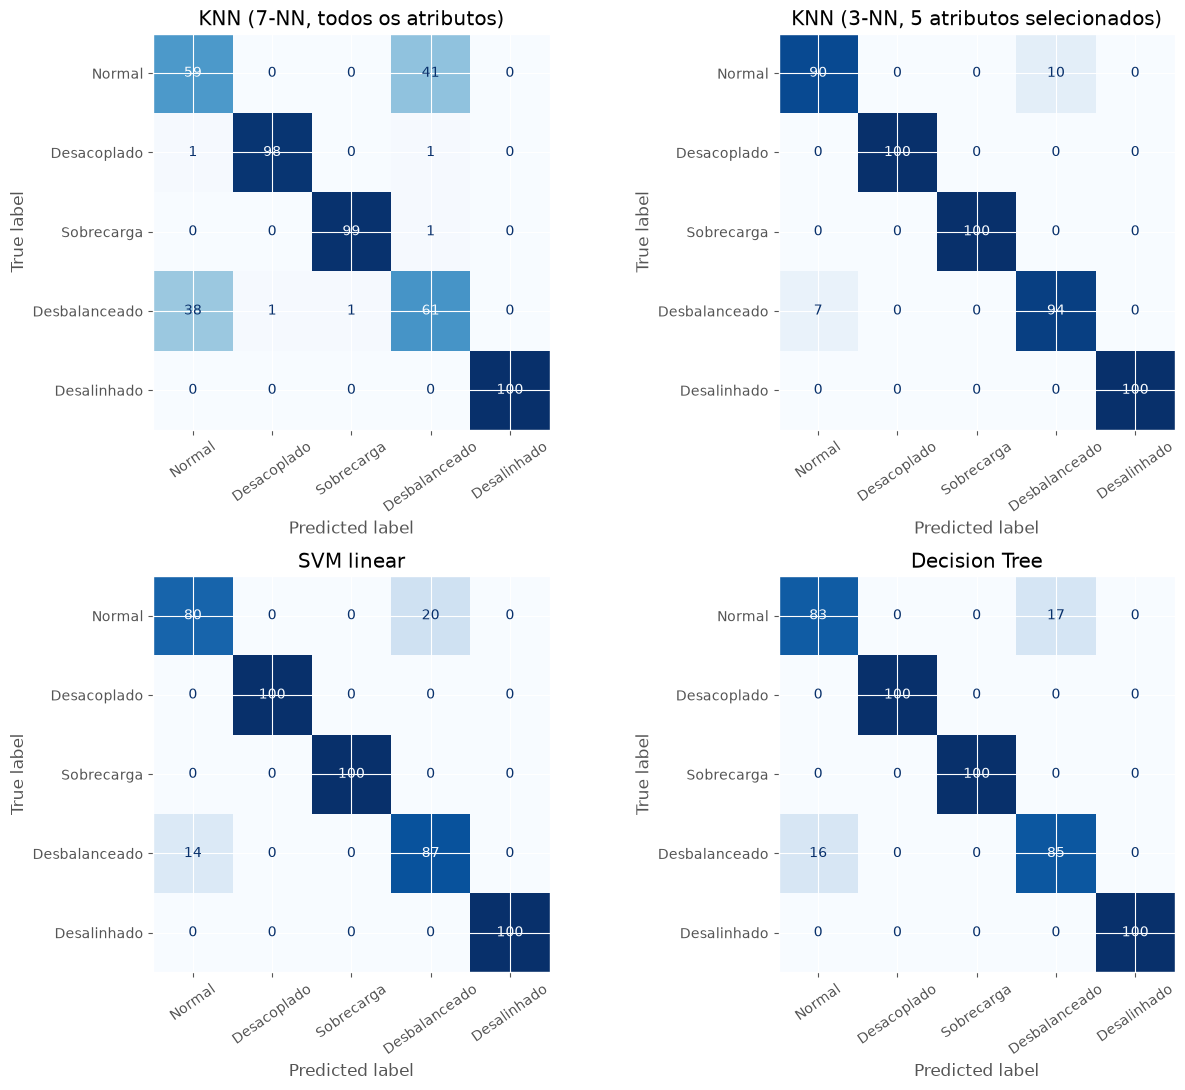

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
axes = axes.ravel()
rotulos = [nomes_classes[i] for i in sorted(nomes_classes)]

for eixo, (nome, previsao) in zip(axes, previsoes.items()):
    matriz = confusion_matrix(y_test, previsao, labels=list(sorted(nomes_classes)))
    ConfusionMatrixDisplay(
        confusion_matrix=matriz,
        display_labels=rotulos,
    ).plot(ax=eixo, cmap="Blues", colorbar=False, xticks_rotation=35)
    eixo.set_title(nome)

plt.tight_layout()
plt.show()

In [17]:
for nome, previsao in previsoes.items():
    print(f"\n===== {nome} =====")
    print(
        classification_report(
            y_test,
            previsao,
            labels=list(sorted(nomes_classes)),
            target_names=rotulos,
            zero_division=0,
        )
    )


===== KNN (7-NN, todos os atributos) =====
               precision    recall  f1-score   support

       Normal       0.60      0.59      0.60       100
  Desacoplado       0.99      0.98      0.98       100
   Sobrecarga       0.99      0.99      0.99       100
Desbalanceado       0.59      0.60      0.60       101
  Desalinhado       1.00      1.00      1.00       100

     accuracy                           0.83       501
    macro avg       0.83      0.83      0.83       501
 weighted avg       0.83      0.83      0.83       501


===== KNN (3-NN, 5 atributos selecionados) =====
               precision    recall  f1-score   support

       Normal       0.93      0.90      0.91       100
  Desacoplado       1.00      1.00      1.00       100
   Sobrecarga       1.00      1.00      1.00       100
Desbalanceado       0.90      0.93      0.92       101
  Desalinhado       1.00      1.00      1.00       100

     accuracy                           0.97       501
    macro avg       0

## 7. Curva ROC e AUC

A curva ROC compara a taxa de verdadeiros positivos com a taxa de falsos positivos ao variar o limiar de decisão. Como este problema possui cinco classes, será usada a abordagem **um contra todos (one-vs-rest)**: cada classe é comparada contra as outras. A AUC resume a área sob cada curva.

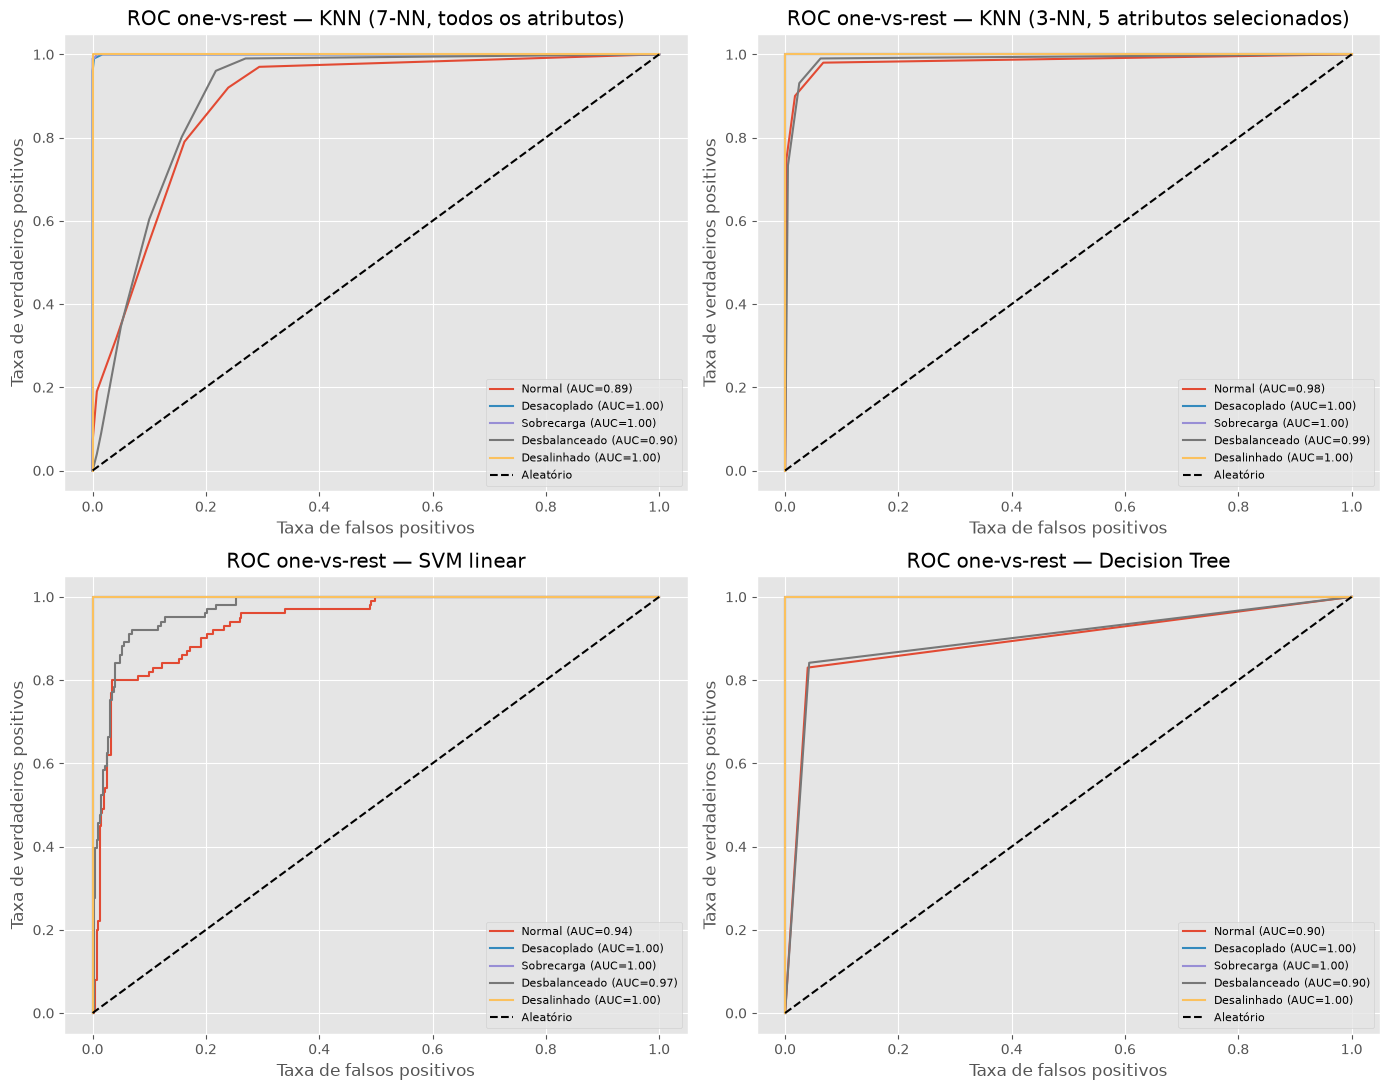

AUC macro no conjunto de teste:


,modelo,AUC macro
1,"KNN (3-NN, 5 atributos selecionados)",0.9942
2,SVM linear,0.9816
3,Decision Tree,0.9589
0,"KNN (7-NN, todos os atributos)",0.9585


,modelo,acuracia_treino,acuracia_teste,f1_macro_teste,precisao_macro_teste,recall_macro_teste,acuracia_cv_media,acuracia_cv_desvio,AUC macro
0,"KNN (3-NN, 5 atributos selecionados)",0.9865,0.9661,0.9662,0.9663,0.9661,0.9681,0.0073,0.9942
1,Decision Tree,1.0000,0.9341,0.9343,0.9343,0.9343,0.9285,0.0093,0.9589
2,SVM linear,0.9436,0.9321,0.9323,0.9328,0.9323,0.9373,0.0083,0.9816
3,"KNN (7-NN, todos os atributos)",0.8972,0.8323,0.8332,0.8337,0.8328,0.8355,0.0076,0.9585


In [18]:
classes = np.array(sorted(nomes_classes))
y_test_binario = label_binarize(y_test, classes=classes)

def obter_scores_roc(modelo, dados):
    # SVM linear fornece score de decisão; KNN e árvore fornecem probabilidades.
    if hasattr(modelo, "predict_proba"):
        return modelo.predict_proba(dados)
    return modelo.decision_function(dados)

auc_resultados = []
fig, eixos = plt.subplots(2, 2, figsize=(14, 11))

for eixo, (nome, modelo) in zip(eixos.ravel(), modelos_treinados.items()):
    scores = obter_scores_roc(modelo, X_test)
    auc_macro = roc_auc_score(
        y_test_binario, scores, multi_class="ovr", average="macro"
    )
    auc_resultados.append({"modelo": nome, "AUC macro": auc_macro})

    for indice, classe in enumerate(classes):
        falso_positivo, verdadeiro_positivo, _ = roc_curve(
            y_test_binario[:, indice], scores[:, indice]
        )
        eixo.plot(
            falso_positivo,
            verdadeiro_positivo,
            label=f"{nomes_classes[int(classe)]} (AUC={auc(falso_positivo, verdadeiro_positivo):.2f})",
        )

    eixo.plot([0, 1], [0, 1], "k--", label="Aleatório")
    eixo.set_title(f"ROC one-vs-rest — {nome}")
    eixo.set_xlabel("Taxa de falsos positivos")
    eixo.set_ylabel("Taxa de verdadeiros positivos")
    eixo.legend(fontsize=8)

plt.tight_layout()
plt.show()

auc_resultados = pd.DataFrame(auc_resultados).sort_values("AUC macro", ascending=False)
print("AUC macro no conjunto de teste:")
display(auc_resultados.round(4))

# Inclui a AUC na tabela geral de resultados.
resultados = resultados.merge(auc_resultados, on="modelo")
display(resultados.round(4))

## 8. Curva de aprendizado

A curva de aprendizado mostra como o desempenho de treino e validação muda quando aumentamos a quantidade de dados. Ela ajuda a observar overfitting, underfitting e se mais dados podem ajudar. A curva abaixo usa o modelo escolhido pela validação cruzada e validação cruzada estratificada com 5 folds.

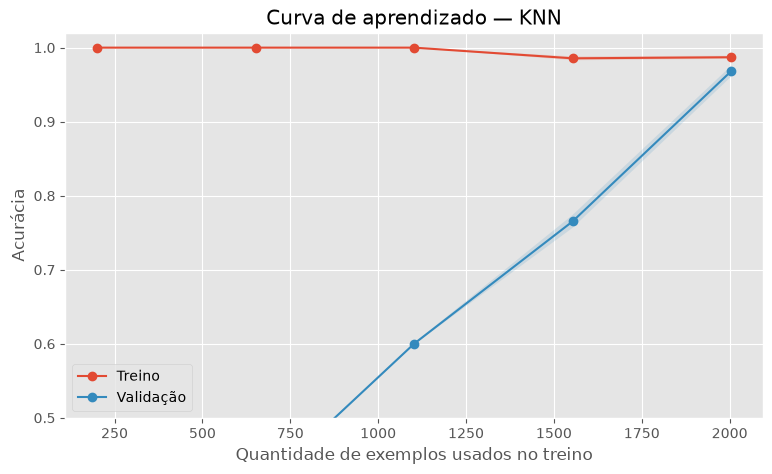

In [19]:
modelo_para_curva = modelos[melhor_nome] if "melhor_nome" in globals() else modelos["KNN (3-NN, 5 atributos selecionados)"]
tamanhos, notas_treino, notas_validacao = learning_curve(
    modelo_para_curva,
    X,
    y,
    cv=cv,
    train_sizes=np.linspace(0.1, 1.0, 5),
    scoring="accuracy",
)

media_treino = notas_treino.mean(axis=1)
desvio_treino = notas_treino.std(axis=1)
media_validacao = notas_validacao.mean(axis=1)
desvio_validacao = notas_validacao.std(axis=1)

plt.figure(figsize=(9, 5))
plt.plot(tamanhos, media_treino, "o-", label="Treino")
plt.plot(tamanhos, media_validacao, "o-", label="Validação")
plt.fill_between(tamanhos, media_treino - desvio_treino, media_treino + desvio_treino, alpha=0.15)
plt.fill_between(tamanhos, media_validacao - desvio_validacao, media_validacao + desvio_validacao, alpha=0.15)
plt.title(f"Curva de aprendizado — {melhor_nome if 'melhor_nome' in globals() else 'KNN'}")
plt.xlabel("Quantidade de exemplos usados no treino")
plt.ylabel("Acurácia")
plt.ylim(0.5, 1.02)
plt.legend()
plt.show()

## 9. Atributos selecionados

O `SelectKBest` escolhe os atributos com maior relação estatística com o rótulo. A seleção abaixo é ajustada somente no conjunto de treino, como deve ser em um experimento de aprendizado de máquina.

In [20]:
seletor = SelectKBest(score_func=f_classif, k=5)
seletor.fit(X_train, y_train)

atributos_selecionados = X.columns[seletor.get_support()].tolist()
pontuacoes = (
    pd.DataFrame({
        "atributo": X.columns,
        "pontuacao_F": seletor.scores_,
    })
      .sort_values("pontuacao_F", ascending=False)
)

print("5 atributos selecionados:")
print(atributos_selecionados)
print("\nPontuações dos atributos:")
display(pontuacoes.round(2))

5 atributos selecionados:
['Mag_S1_f2_dBrms', 'Mag_S1_f3_dBrms', 'Mag_S2_f1_dBrms', 'Mag_S2_f2_dBrms', 'Mag_S2_f3_dBrms']

Pontuações dos atributos:


,atributo,pontuacao_F
13,Mag_S1_f2_dBrms,13843.44
16,Mag_S2_f2_dBrms,13212.07
15,Mag_S2_f1_dBrms,7920.85
14,Mag_S1_f3_dBrms,6194.69
17,Mag_S2_f3_dBrms,6038.96
12,Mag_S1_f1_dBrms,4476.17
0,I_entrada_A,1107.13
1,P_entrada_W,770.39
2,I_saida_A,5.39
4,DesvPad _P_entrada_W,2.71


## 10. Visualização simples da árvore de decisão

A árvore usada no modelo é completa. Para a visualização não ficar excessivamente grande, o gráfico mostra apenas os três primeiros níveis. Isso limita apenas a exibição, não o treinamento do modelo.

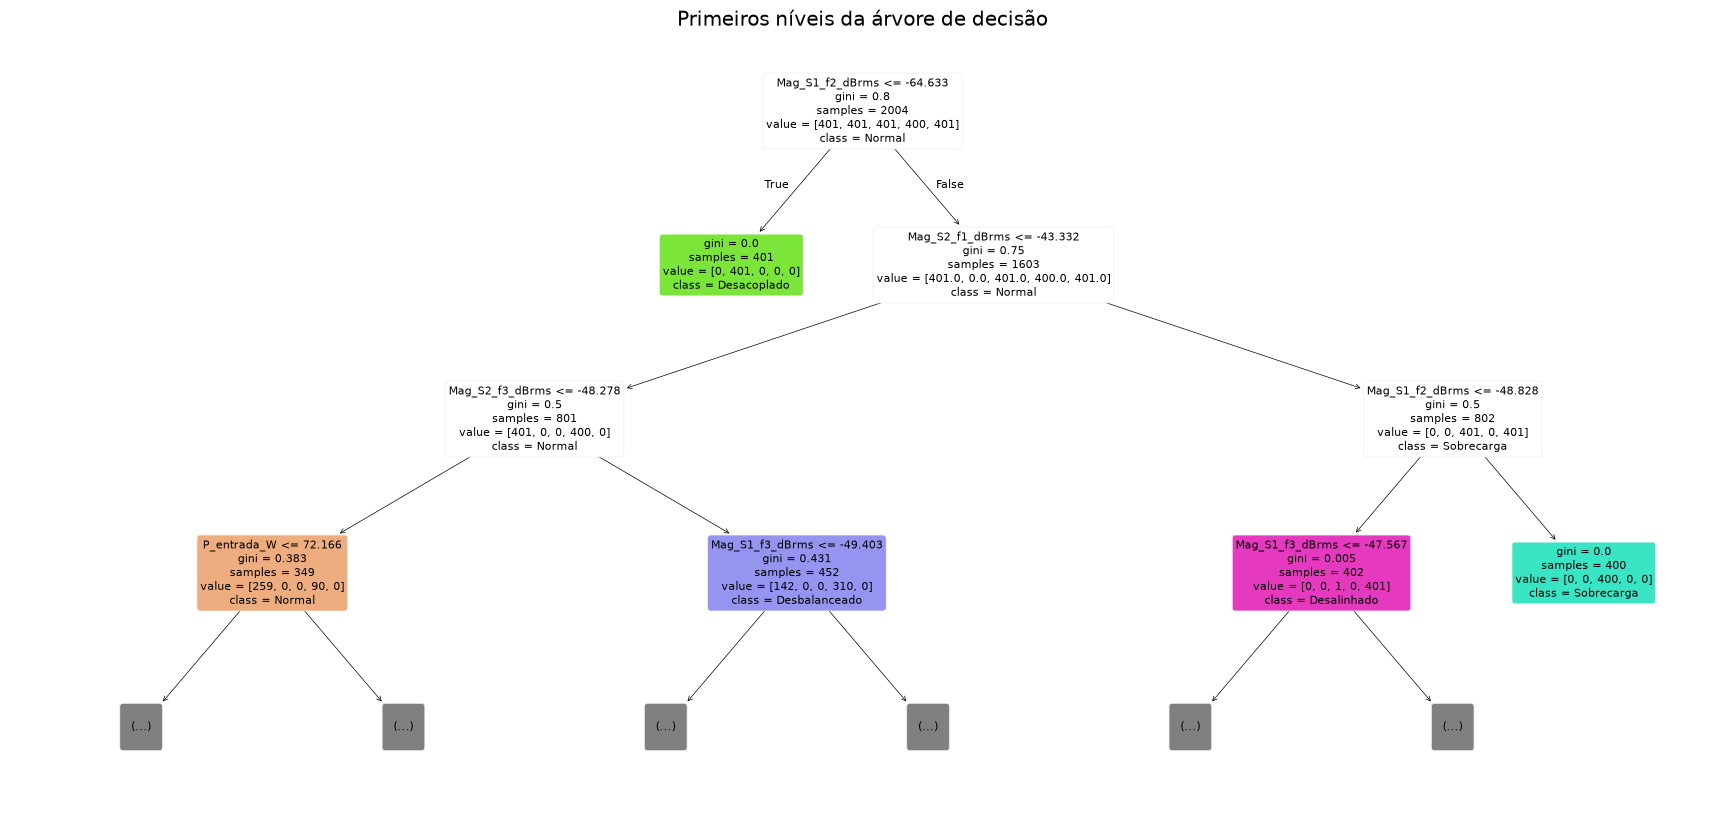

In [21]:
plt.figure(figsize=(22, 10))
plot_tree(
    modelos_treinados["Decision Tree"],
    feature_names=X.columns,
    class_names=rotulos,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8,
)
plt.title("Primeiros níveis da árvore de decisão")
plt.show()

## 11. Função para classificar uma nova entrada

Para a função, será usado o modelo com maior acurácia média na validação cruzada. Depois da avaliação, ele é treinado novamente com todos os registros disponíveis, para aproveitar toda a base antes de classificar novas entradas.

A função aceita tanto um dicionário com os nomes dos atributos quanto uma lista na mesma ordem da tabela.

In [22]:
melhor_nome = resultados.sort_values("acuracia_cv_media", ascending=False).iloc[0]["modelo"]
modelo_final = modelos[melhor_nome]
modelo_final.fit(X, y)

print(f"Modelo escolhido pela validação cruzada: {melhor_nome}")

def classificar_falha(valores_atributos):
    """Classifica uma nova medição e retorna o nome da condição."""
    if isinstance(valores_atributos, dict):
        entrada = pd.DataFrame([valores_atributos])
        entrada = entrada[atributos_originais]
    else:
        if len(valores_atributos) != len(atributos_originais):
            raise ValueError(
                f"Informe exatamente {len(atributos_originais)} valores, um para cada atributo."
            )
        entrada = pd.DataFrame([valores_atributos], columns=atributos_originais)

    codigo_previsto = int(modelo_final.predict(entrada)[0])
    return nomes_classes[codigo_previsto]

# Exemplo usando uma linha do conjunto de teste como nova entrada.
nova_entrada = X_test.iloc[0].to_dict()
print("Condição real:     ", nomes_classes[int(y_test.iloc[0])])
print("Condição prevista: ", classificar_falha(nova_entrada))

Modelo escolhido pela validação cruzada: KNN (3-NN, 5 atributos selecionados)
Condição real:      Desalinhado
Condição prevista:  Desalinhado


### Por que a retirada dos sensores elétricos não alterou a acurácia?

A seleção de atributos com `SelectKBest` mostrou que os cinco atributos mais relevantes pertencem aos dois sensores de vibração:

- `Mag_S1_f2_dBrms`
- `Mag_S1_f3_dBrms`
- `Mag_S2_f1_dBrms`
- `Mag_S2_f2_dBrms`
- `Mag_S2_f3_dBrms`

Nenhum atributo dos sensores elétricos foi selecionado entre os cinco melhores. Isso indica que, neste conjunto de dados, as informações necessárias para diferenciar as cinco condições da máquina já estão suficientemente representadas pelos sensores de vibração.

Por isso, quando o KNN foi treinado novamente usando somente esses cinco atributos, suas previsões permaneceram iguais:

- Acurácia com todos os atributos e `SelectKBest`: **96,61%**
- Acurácia usando diretamente os cinco atributos: **96,61%**
- F1-score: **96,62%**
- Validação cruzada: aproximadamente **96,81%**

A retirada não prejudicou o modelo porque os atributos elétricos não estavam contribuindo significativamente para a decisão final. Eles foram apresentados ao processo de seleção, mas não foram utilizados pelo classificador final.

É importante destacar que essa conclusão é válida para este dataset e para as condições testadas. Isso não significa que os sensores elétricos sejam inúteis em qualquer máquina ou situação. Para retirá-los fisicamente do sistema, seria necessário validar o modelo com novas medições e diferentes condições de operação.

In [23]:
atributos_reduzidos = atributos_selecionados.copy()

def identificar_sensor(atributo):
    if atributo.startswith("Mag_S1_"):
        return "Sensor de vibração 1"
    if atributo.startswith("Mag_S2_"):
        return "Sensor de vibração 2"
    return "Grandezas elétricas"

relacao_atributos_sensores = pd.DataFrame({
    "atributo": atributos_reduzidos,
    "sensor": [identificar_sensor(a) for a in atributos_reduzidos],
})

display(relacao_atributos_sensores)

atributos_sensor_1 = [
    a for a in atributos_originais if a.startswith("Mag_S1_")
]

atributos_sensor_2 = [
    a for a in atributos_originais if a.startswith("Mag_S2_")
]

atributos_eletricos = [
    a for a in atributos_originais
    if a not in atributos_sensor_1 + atributos_sensor_2
]

resumo_sensores = pd.DataFrame({
    "grupo": [
        "Sensor de vibração 1",
        "Sensor de vibração 2",
        "Transdutores elétricos",
    ],
    "atributos_mantidos": [
        ", ".join(
            [a for a in atributos_reduzidos if a in atributos_sensor_1]
        ) or "nenhum",

        ", ".join(
            [a for a in atributos_reduzidos if a in atributos_sensor_2]
        ) or "nenhum",

        "nenhum",
    ],
    "decisao": [
        "mantido",
        "mantido",
        "fora do modelo final",
    ],
})

display(resumo_sensores)

,atributo,sensor
0,Mag_S1_f2_dBrms,Sensor de vibração 1
1,Mag_S1_f3_dBrms,Sensor de vibração 1
2,Mag_S2_f1_dBrms,Sensor de vibração 2
3,Mag_S2_f2_dBrms,Sensor de vibração 2
4,Mag_S2_f3_dBrms,Sensor de vibração 2


,grupo,atributos_mantidos,decisao
0,Sensor de vibração 1,"Mag_S1_f2_dBrms, Mag_S1_f3_dBrms",mantido
1,Sensor de vibração 2,"Mag_S2_f1_dBrms, Mag_S2_f2_dBrms, Mag_S2_f3_dBrms",mantido
2,Transdutores elétricos,nenhum,fora do modelo final


In [24]:
modelo_sensor_reduzido = Pipeline([
    ("escala", StandardScaler()),
    ("modelo", KNeighborsClassifier(n_neighbors=3)),
])

modelo_sensor_reduzido.fit(
    X_train[atributos_reduzidos],
    y_train
)

previsao_sensor_reduzido = modelo_sensor_reduzido.predict(
    X_test[atributos_reduzidos]
)

print(
    "Acurácia:",
    accuracy_score(y_test, previsao_sensor_reduzido)
)

print(
    "F1-score:",
    f1_score(
        y_test,
        previsao_sensor_reduzido,
        average="macro"
    )
)

Acurácia: 0.9660678642714571
F1-score: 0.9661557508976106


In [25]:
modelo_selectkbest = clone(
    modelos["KNN (3-NN, 5 atributos selecionados)"]
)

modelo_selectkbest.fit(X_train, y_train)

previsao_selectkbest = modelo_selectkbest.predict(X_test)

print(
    "As previsões foram iguais?",
    np.array_equal(
        previsao_selectkbest,
        previsao_sensor_reduzido
    )
)

As previsões foram iguais? True


## Conclusão

O notebook realiza a exploração, o pré-processamento e a comparação de KNN, SVM e Decision Tree. A qualidade é analisada por holdout, validação cruzada, acurácia, precisão, recall, F1, matriz de confusão, curva ROC/AUC e curva de aprendizado. A escolha final é baseada na validação cruzada, e a função `classificar_falha` permite testar uma nova medição.

A análise já compara valores básicos de `k`, `C`, `max_depth` e StandardScaler/MinMaxScaler. Como próximos passos, pode-se testar poda por custo-complexidade (`ccp_alpha`), validação repetida e intervalos de confiança. Nesta versão os ajustes foram mantidos simples para facilitar a compreensão.

**Materiais usados como referência:** APS1 — Projeto de Aprendizado de Máquina; Aula 7 — kNN e Decision Tree; Aula 8 — SVM; Aula 9 — Exploração e Preparação de Dados; Aula 10 — Redução de Dimensionalidade, Agregação e Seleção de Atributos.